In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from collections import defaultdict

print("Ready")

Ready


In [2]:
class LimitOrderBook:
    """
    Simplified limit order book simulator.
    Tracks bids and asks, matches orders,
    and records trade history.
    """
    def __init__(self):
        self.bids   = defaultdict(int)  # price -> shares
        self.asks   = defaultdict(int)  # price -> shares
        self.trades = []
        self.time   = 0

    def best_bid(self):
        return max(self.bids.keys()) if self.bids else None

    def best_ask(self):
        return min(self.asks.keys()) if self.asks else None

    def mid_price(self):
        bb = self.best_bid()
        ba = self.best_ask()
        if bb and ba:
            return (bb + ba) / 2
        return None

    def spread(self):
        bb = self.best_bid()
        ba = self.best_ask()
        if bb and ba:
            return ba - bb
        return None

    def add_limit_order(self, side, price, shares):
        """Add a limit order to the book."""
        price = round(price, 2)
        if side == "buy":
            self.bids[price] += shares
        else:
            self.asks[price] += shares
        self._match()

    def add_market_order(self, side, shares):
        """Execute a market order against best available."""
        filled = 0
        fills  = []

        if side == "buy":
            while shares > 0 and self.asks:
                best = self.best_ask()
                available = self.asks[best]
                fill = min(shares, available)
                self.asks[best] -= fill
                if self.asks[best] == 0:
                    del self.asks[best]
                filled  += fill
                shares  -= fill
                fills.append((best, fill))
                self.trades.append({
                    "time"  : self.time,
                    "price" : best,
                    "shares": fill,
                    "side"  : "buy"
                })
        else:
            while shares > 0 and self.bids:
                best = self.best_bid()
                available = self.bids[best]
                fill = min(shares, available)
                self.bids[best] -= fill
                if self.bids[best] == 0:
                    del self.bids[best]
                filled  += fill
                shares  -= fill
                fills.append((best, fill))
                self.trades.append({
                    "time"  : self.time,
                    "price" : best,
                    "shares": fill,
                    "side"  : "sell"
                })

        self.time += 1
        return fills

    def _match(self):
        """Match any crossing orders."""
        while self.bids and self.asks:
            bb = self.best_bid()
            ba = self.best_ask()
            if bb >= ba:
                fill = min(self.bids[bb], self.asks[ba])
                self.bids[bb] -= fill
                self.asks[ba] -= fill
                if self.bids[bb] == 0:
                    del self.bids[bb]
                if self.asks[ba] == 0:
                    del self.asks[ba]
                self.trades.append({
                    "time"  : self.time,
                    "price" : ba,
                    "shares": fill,
                    "side"  : "match"
                })
                self.time += 1
            else:
                break

    def display(self):
        """Print current order book state."""
        print(f"\n  ORDER BOOK (time={self.time})")
        print(f"  {'='*35}")
        asks_sorted = sorted(self.asks.keys(), reverse=True)
        for p in asks_sorted[:5]:
            print(f"  ASK  ${p:.2f}  {self.asks[p]:>6} shares")
        bb = self.best_bid()
        ba = self.best_ask()
        if bb and ba:
            print(f"  --- spread: ${ba-bb:.2f} "
                  f"mid: ${(bb+ba)/2:.2f} ---")
        bids_sorted = sorted(self.bids.keys(), reverse=True)
        for p in bids_sorted[:5]:
            print(f"  BID  ${p:.2f}  {self.bids[p]:>6} shares")
        print(f"  {'='*35}")

print("LimitOrderBook ready")

LimitOrderBook ready


Initial order book:

  ORDER BOOK (time=0)
  ASK  $450.05     500 shares
  ASK  $450.04     500 shares
  ASK  $450.03     500 shares
  ASK  $450.02     500 shares
  ASK  $450.01     500 shares
  --- spread: $0.02 mid: $450.00 ---
  BID  $449.99     500 shares
  BID  $449.98     500 shares
  BID  $449.97     500 shares
  BID  $449.96     500 shares
  BID  $449.95     500 shares

Simulating order flow...

  ORDER BOOK (time=100)
  ASK  $450.05     500 shares
  ASK  $450.04     500 shares
  ASK  $450.03   20500 shares
  ASK  $450.02   20500 shares
  ASK  $450.01   13077 shares
  --- spread: $0.02 mid: $450.00 ---
  BID  $449.99   10294 shares
  BID  $449.98   20500 shares
  BID  $449.97   20500 shares
  BID  $449.96     500 shares
  BID  $449.95     500 shares


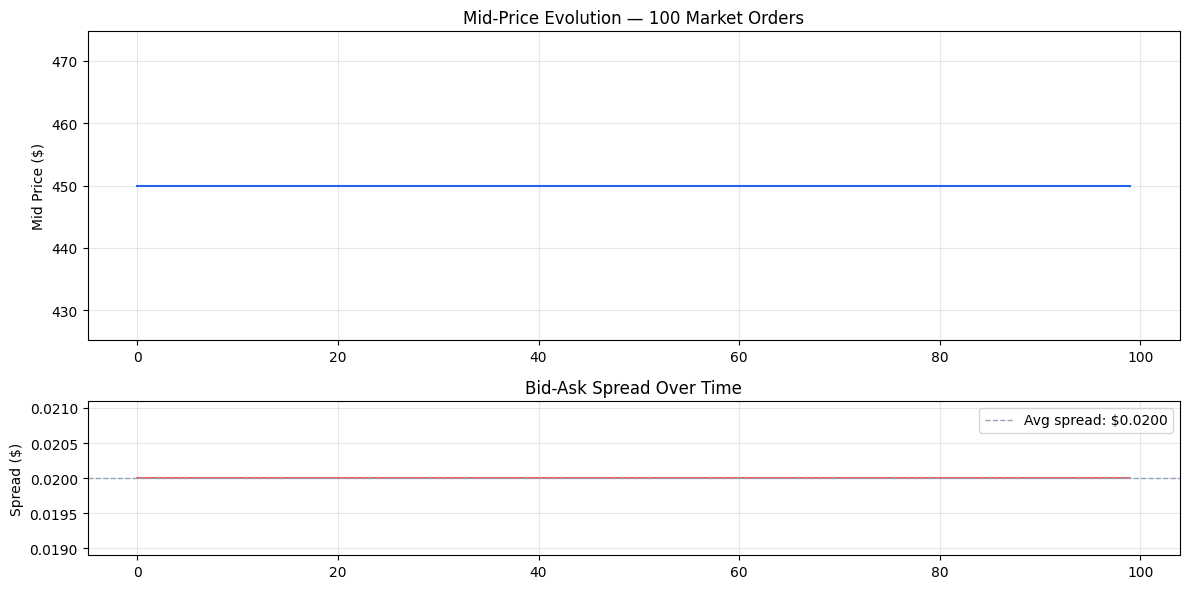


Total trades executed : 100
Average spread        : $0.0200
Final mid price       : $450.0000


In [3]:
# Seed the order book with initial liquidity
lob = LimitOrderBook()

# Add market maker quotes around $450
base_price = 450.00
for i in range(1, 6):
    # Asks above mid
    lob.add_limit_order("sell", base_price + i*0.01, 500)
    # Bids below mid
    lob.add_limit_order("buy",  base_price - i*0.01, 500)

print("Initial order book:")
lob.display()

# Simulate some market orders arriving
print("\nSimulating order flow...")
np.random.seed(42)
mid_prices = []
spreads    = []

for t in range(100):
    # Random market order
    side   = "buy" if np.random.random() > 0.5 else "sell"
    shares = np.random.randint(50, 300)
    lob.add_market_order(side, shares)

    # Market makers refresh quotes
    mid = lob.mid_price()
    if mid:
        for i in range(1, 4):
            lob.add_limit_order("sell", mid + i*0.01, 200)
            lob.add_limit_order("buy",  mid - i*0.01, 200)
        mid_prices.append(mid)
        spreads.append(lob.spread())

# Final book state
lob.display()

# Plot mid-price evolution
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6),
    gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(mid_prices, color='#2563eb', lw=1.5)
ax1.set_title('Mid-Price Evolution — 100 Market Orders')
ax1.set_ylabel('Mid Price ($)')
ax1.grid(True, alpha=0.3)

ax2.plot(spreads, color='#ef4444', lw=1.2)
ax2.axhline(np.mean(spreads), color='#94a3b8',
            lw=1, linestyle='--',
            label=f'Avg spread: ${np.mean(spreads):.4f}')
ax2.set_title('Bid-Ask Spread Over Time')
ax2.set_ylabel('Spread ($)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal trades executed : {len(lob.trades)}")
print(f"Average spread        : ${np.mean(spreads):.4f}")
print(f"Final mid price       : ${mid_prices[-1]:.4f}")

In [4]:
# Roll's spread estimator on real data
def rolls_spread(prices):
    """
    Estimate effective bid-ask spread from daily prices.
    Roll (1984): spread = 2 * sqrt(-cov(dP_t, dP_t-1))
    Exploits negative serial correlation from bid-ask bounce.
    """
    delta_p = prices.diff().dropna()
    cov     = delta_p.cov(delta_p.shift(1).dropna()
                          .reindex(delta_p.index))
    if cov < 0:
        spread = 2 * np.sqrt(-cov)
    else:
        spread = 0  # No negative cov — can't estimate
    return spread

# Compare spread estimates across assets
tickers = {
    "SPY"  : "S&P 500 ETF (very liquid)",
    "IWM"  : "Russell 2000 ETF (liquid)",
    "GLD"  : "Gold ETF (liquid)",
    "IEF"  : "7-10yr Treasury ETF (liquid)",
    "XBI"  : "Biotech ETF (less liquid)",
}

raw = yf.download(list(tickers.keys()),
                   start="2022-01-01",
                   end="2024-01-01",
                   auto_adjust=True)
prices_all = raw["Close"]
prices_all.columns = prices_all.columns.get_level_values(0)

print(f"\n{'='*65}")
print(f"  ROLL'S SPREAD ESTIMATOR — LIQUIDITY COMPARISON")
print(f"{'='*65}")
print(f"  {'Ticker':<8} {'Description':<30} {'Est Spread':>10} {'Spread %':>10}")
print(f"  {'-'*60}")

for ticker, desc in tickers.items():
    if ticker in prices_all.columns:
        p      = prices_all[ticker].dropna()
        spread = rolls_spread(p)
        avg_p  = p.mean()
        pct    = spread / avg_p * 100 if avg_p > 0 else 0
        print(f"  {ticker:<8} {desc:<30} "
              f"${spread:>8.4f}   {pct:>8.4f}%")

print(f"{'='*65}")
print(f"\nLower spread % = more liquid = cheaper to trade")

Failed to get ticker 'IEF' reason: Failed to perform, curl: (28) Connection timed out after 30004 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[*********************100%***********************]  5 of 5 completed


  ROLL'S SPREAD ESTIMATOR — LIQUIDITY COMPARISON
  Ticker   Description                    Est Spread   Spread %
  ------------------------------------------------------------
  SPY      S&P 500 ETF (very liquid)      $  0.0000     0.0000%
  IWM      Russell 2000 ETF (liquid)      $  0.0000     0.0000%
  GLD      Gold ETF (liquid)              $  0.3803     0.2184%
  IEF      7-10yr Treasury ETF (liquid)   $  0.1985     0.2253%
  XBI      Biotech ETF (less liquid)      $  0.6194     0.7632%

Lower spread % = more liquid = cheaper to trade


In [6]:
# Market impact model — how does order size affect cost?
def market_impact(order_size_usd, adv_usd,
                   daily_vol, sigma=0.1):
    """
    Square-root market impact model.
    impact = sigma * vol * sqrt(order / ADV)
    """
    participation = order_size_usd / adv_usd
    impact        = sigma * daily_vol * np.sqrt(participation)
    return impact

# SPY approximate daily metrics
spy_adv      = 25_000_000_000  # $25B average daily volume
spy_vol      = 0.01            # 1% daily vol

# Show impact for different order sizes
order_sizes = [10_000, 100_000, 1_000_000,
               10_000_000, 100_000_000]

print(f"\n{'='*60}")
print(f"  MARKET IMPACT — SPY (ADV: ${spy_adv/1e9:.0f}B)")
print(f"{'='*60}")
print(f"  {'Order Size':>15} {'% of ADV':>10} "
      f"{'Impact (bps)':>14} {'Impact $':>12}")
print(f"  {'-'*55}")

for order in order_sizes:
    impact_pct = market_impact(order, spy_adv, spy_vol)
    impact_bps = impact_pct * 10000
    impact_usd = impact_pct * order
    pct_adv    = order / spy_adv * 100
    print(f"  ${order:>14,.0f} {pct_adv:>9.4f}% "
          f"{impact_bps:>14.2f} ${impact_usd:>11,.2f}")

print(f"{'='*60}")
print(f"\nFor retail traders (<$1M orders) on SPY:")
print(f"Market impact is negligible (<1 bps)")
print(f"Transaction costs dominated by spread, not impact")


  MARKET IMPACT — SPY (ADV: $25B)
       Order Size   % of ADV   Impact (bps)     Impact $
  -------------------------------------------------------
  $        10,000    0.0000%           0.01 $       0.01
  $       100,000    0.0004%           0.02 $       0.20
  $     1,000,000    0.0040%           0.06 $       6.32
  $    10,000,000    0.0400%           0.20 $     200.00
  $   100,000,000    0.4000%           0.63 $   6,324.56

For retail traders (<$1M orders) on SPY:
Market impact is negligible (<1 bps)
Transaction costs dominated by spread, not impact
